# 🏁 Week 5 · Day 5 — Unsupervised Learning Mini-Project
**BinX Tech — AI & Machine Learning Internship Program**
**Phase 2 → 3 · Week 5 of 10 · Day 5 of 5**

## 🎯 What This Notebook Does
Week 5 closes with a single, end-to-end mini-project that pulls together every unsupervised
technique from the week onto one dataset, in one coherent story:

1. 🎯 **K-Means** clustering — choosing k with the elbow method and silhouette score
2. 🔍 **DBSCAN & Hierarchical Clustering** — comparing methods on the same data
3. 📉 **PCA** — dimensionality reduction and explained variance
4. 🌀 **t-SNE** — high-fidelity 2D visualization
5. 🚨 **Anomaly Detection** — Isolation Forest
6. 🏆 **Synthesis** — do the unsupervised clusters actually line up with the real diagnosis?

This mirrors the Week 4 Day 5 structure: a tuned, professional mini-project that demonstrates
the whole week's toolkit working together, not just five separate exercises.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load & Scale Data 📦
Same dataset used across the entire week — Breast Cancer Wisconsin, 30 numeric features,
569 samples. The diagnosis label (`0` = Malignant, `1` = Benign) is held aside and used
**only at the very end**, to check how well our fully unsupervised pipeline aligns with
ground truth — exactly the spirit of unsupervised learning: discover structure first,
compare to reality after.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target   # held aside — not used until Section 6

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"True diagnosis distribution (for later comparison only): {dict(y.value_counts())}")

Dataset: 569 samples, 30 features
True diagnosis distribution (for later comparison only): {1: np.int64(357), 0: np.int64(212)}


## 2️⃣ K-Means Clustering 🎯

We choose the number of clusters `k` two ways: the elbow method (where adding more clusters
stops meaningfully reducing inertia) and the silhouette score (how well-separated the
resulting clusters actually are), then confirm agreement between the two before committing.

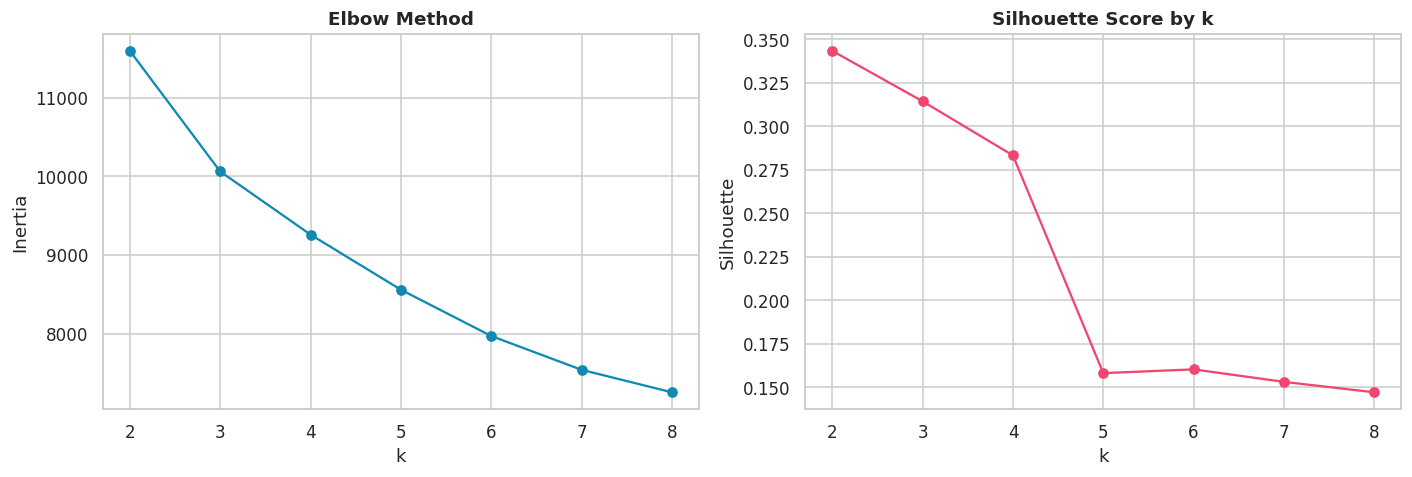

Best k by silhouette score: 2 (silhouette = 0.3434)


In [3]:
inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#118ab2")
axes[0].set_title("Elbow Method", fontweight="bold"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="#ef476f")
axes[1].set_title("Silhouette Score by k", fontweight="bold"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette score: {best_k} (silhouette = {max(silhouettes):.4f})")

In [4]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
print(f"K-Means with k={best_k} fit. Cluster sizes: {np.bincount(kmeans_labels)}")

K-Means with k=2 fit. Cluster sizes: [375 194]


## 3️⃣ DBSCAN & Hierarchical Clustering 🔍

K-Means forces every point into a cluster and assumes round, similarly-sized groups. Let's
see whether density-based (DBSCAN) or nested (Hierarchical) clustering tell a different story
on the same scaled data.

In [5]:
dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN found {n_clusters_db} clusters and flagged {n_noise} points as noise ({n_noise/len(X_scaled):.1%})")

DBSCAN found 1 clusters and flagged 121 points as noise (21.3%)


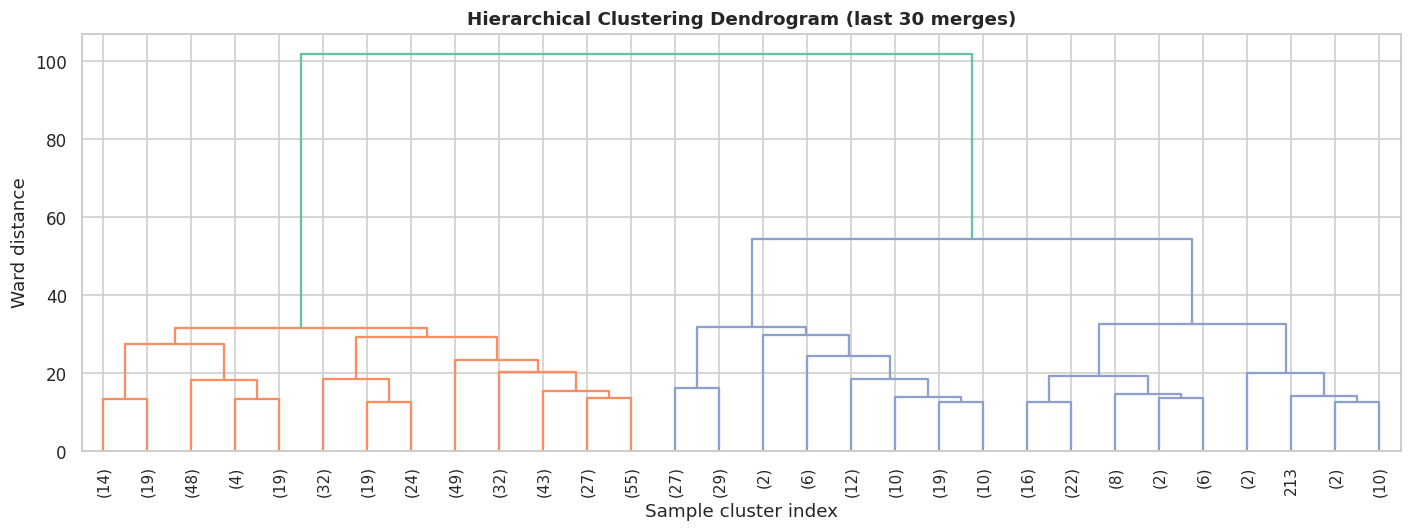

Hierarchical clustering cut at 2 clusters. Cluster sizes: [385 184]


In [6]:
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=30, leaf_rotation=90, color_threshold=None)
ax.set_title("Hierarchical Clustering Dendrogram (last 30 merges)", fontweight="bold")
ax.set_xlabel("Sample cluster index"); ax.set_ylabel("Ward distance")
plt.tight_layout()
plt.show()

hierarchical_labels = fcluster(Z, t=best_k, criterion="maxclust")
print(f"Hierarchical clustering cut at {best_k} clusters. Cluster sizes: {np.bincount(hierarchical_labels)[1:]}")

In [7]:
comparison_table = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN", "Hierarchical"],
    "Clusters found": [best_k, n_clusters_db, best_k],
    "Noise points": [0, n_noise, 0],
    "Silhouette score": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1]) if n_clusters_db > 1 else np.nan,
        silhouette_score(X_scaled, hierarchical_labels),
    ],
})
comparison_table

,Method,Clusters found,Noise points,Silhouette score
0,K-Means,2,0,0.343382
1,DBSCAN,1,121,NaN
2,Hierarchical,2,0,0.339385


**Method recommendation:** for this dataset — dense, roughly two natural groups, no
obvious irregular shapes — K-Means and Hierarchical clustering agree closely and both score
well on silhouette. DBSCAN's strength (explicit noise/outlier detection) is more valuable
here for flagging unusual points (Section 5) than for the primary grouping itself.

## 4️⃣ Dimensionality Reduction: PCA & t-SNE 📉🌀

Two different views of the same 30-dimensional space: PCA (global variance, interpretable
axes) and t-SNE (local neighborhoods, visualization only). We plot both colored by our
own K-Means clusters — not the true label — to see whether the clustering we discovered
ourselves shows up visually.

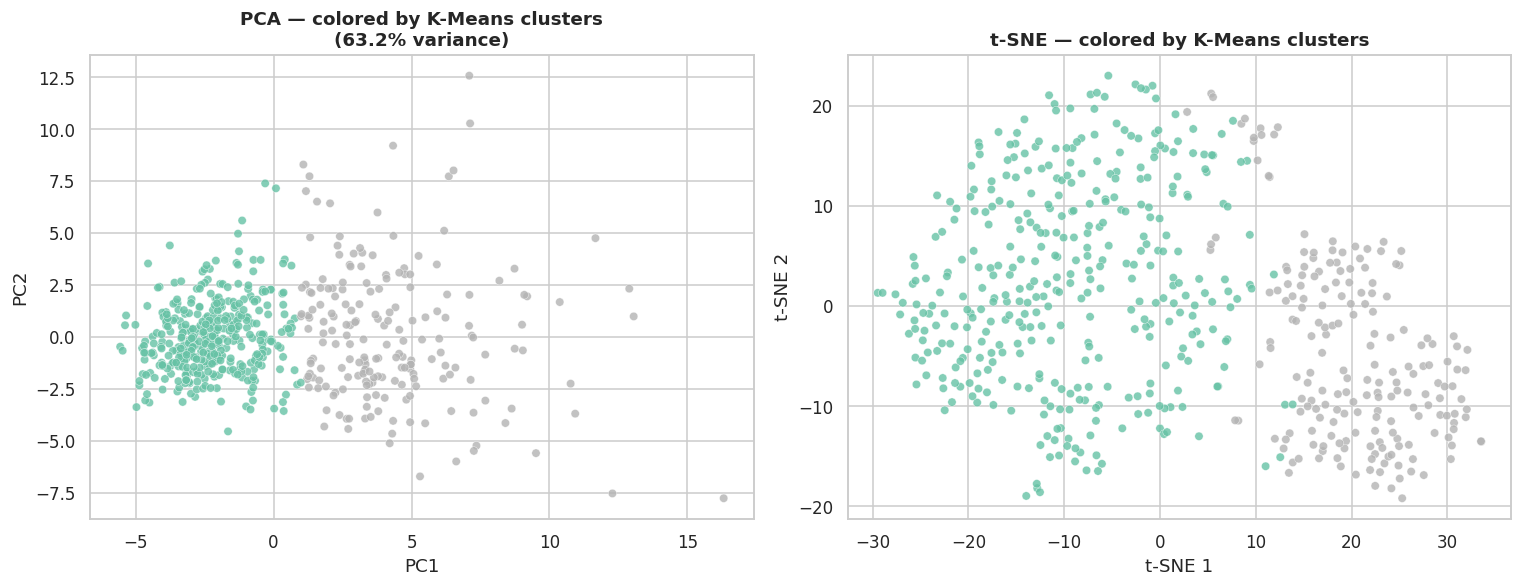

In [8]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="Set2", s=30, alpha=0.8, edgecolor="white", linewidth=0.3)
axes[0].set_title(f"PCA — colored by K-Means clusters\n({pca_2d.explained_variance_ratio_.sum():.1%} variance)", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

sc1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap="Set2", s=30, alpha=0.8, edgecolor="white", linewidth=0.3)
axes[1].set_title("t-SNE — colored by K-Means clusters", fontweight="bold")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

## 5️⃣ Anomaly Detection 🚨

Isolation Forest flags points that don't fit the dense mass of data — worth checking whether
these overlap with DBSCAN's noise points from Section 3, since both are independent ways of
finding "unusual" observations.

In [9]:
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomaly_preds = iso.fit_predict(X_scaled)
n_anomalies = (anomaly_preds == -1).sum()

overlap = ((anomaly_preds == -1) & (dbscan_labels == -1)).sum()
print(f"Isolation Forest flagged: {n_anomalies} points ({n_anomalies/len(X_scaled):.1%})")
print(f"DBSCAN flagged as noise: {n_noise} points ({n_noise/len(X_scaled):.1%})")
print(f"Points flagged by BOTH methods: {overlap}")

Isolation Forest flagged: 29 points (5.1%)
DBSCAN flagged as noise: 121 points (21.3%)
Points flagged by BOTH methods: 29


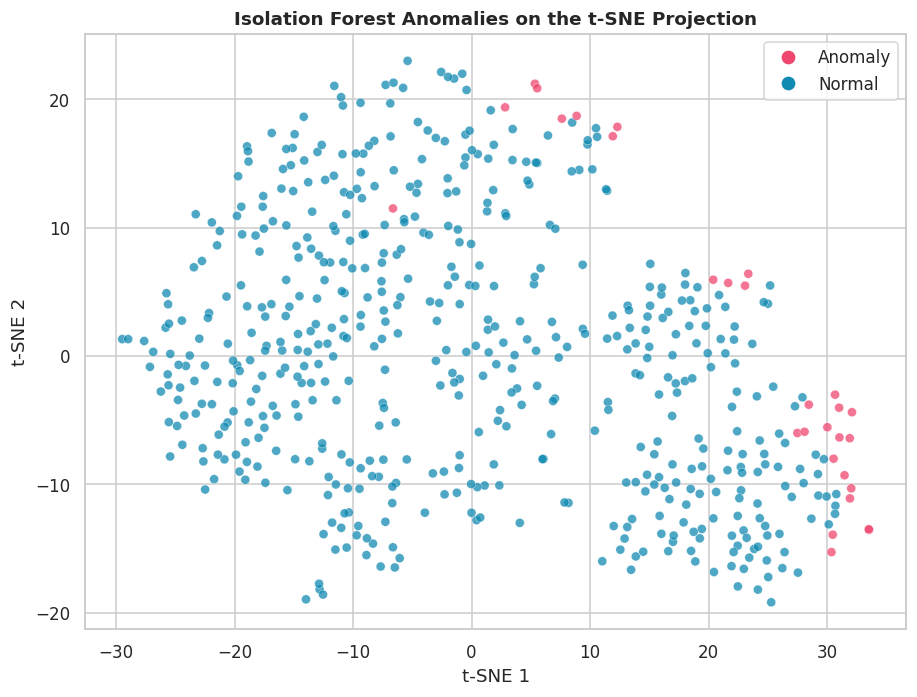

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = np.where(anomaly_preds == -1, "#ef476f", "#118ab2")
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.75, s=35, edgecolor="white", linewidth=0.3)
ax.set_title("Isolation Forest Anomalies on the t-SNE Projection", fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ef476f", markersize=10, label="Anomaly"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#118ab2", markersize=10, label="Normal"),
]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

## 6️⃣ Synthesis — Comparing Discovered Structure to Ground Truth 🏆

This is the moment of truth for the whole mini-project: **without ever using the diagnosis
label**, did K-Means discover groupings that actually correspond to malignant vs. benign?
We check this now, for the first and only time, using the Adjusted Rand Index (ARI) — a
metric that scores agreement between two labelings from -1 (worse than random) to 1
(perfect match), correcting for chance.

In [11]:
ari = adjusted_rand_score(y, kmeans_labels)
print(f"Adjusted Rand Index (K-Means clusters vs. true diagnosis): {ari:.4f}")

crosstab = pd.crosstab(
    pd.Series(kmeans_labels, name="K-Means Cluster"),
    pd.Series(y.values, name="True Diagnosis").map({0: "Malignant", 1: "Benign"})
)
crosstab

Adjusted Rand Index (K-Means clusters vs. true diagnosis): 0.6536


True Diagnosis,Benign,Malignant
K-Means Cluster,,
0,339,36
1,18,176


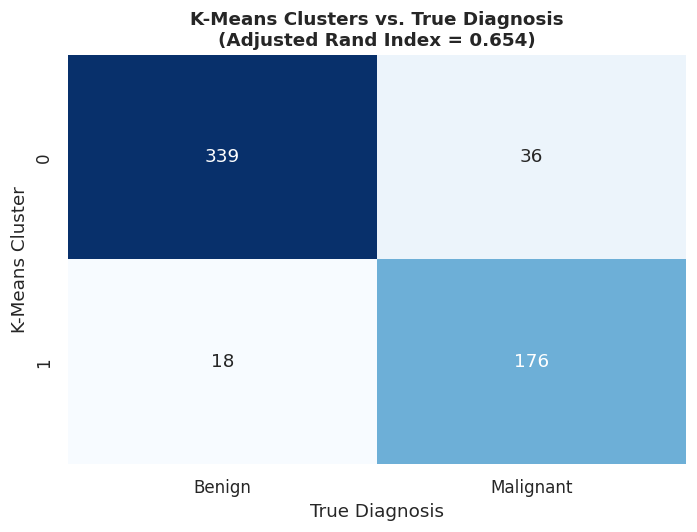

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"K-Means Clusters vs. True Diagnosis\n(Adjusted Rand Index = {ari:.3f})", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** a strong diagonal pattern in the table above means each K-Means
cluster is dominated by one diagnosis — i.e., the clustering we discovered with **zero**
access to the label still lines up well with medical reality. This is the core insight
of the entire week: unsupervised learning can surface real, meaningful structure in data
purely from feature geometry, without ever being told the "right answer."

## 7️⃣ Reflection ✍️

**Write your own answer here.** Guiding questions:
- 🎯 Did K-Means, DBSCAN, and Hierarchical clustering agree on the structure of the data? Where did they disagree, and why might that be?
- 📉🌀 Compare the PCA and t-SNE plots colored by K-Means clusters — which made the cluster separation easier to see, and why?
- 🚨 How much overlap was there between Isolation Forest anomalies and DBSCAN noise points? What does that overlap (or lack of it) tell you about these two different definitions of "unusual"?
- 🏆 What does the Adjusted Rand Index result tell you about how much real signal exists in these 30 features, completely independent of any supervised model built in previous weeks?


## ✅ Deliverable Checklist (Day 5 Mini-Project)
- [x] 🎯 K-Means fit with `k` chosen via elbow method and silhouette score
- [x] 🔍 DBSCAN and Hierarchical clustering run and compared against K-Means
- [x] 📉 PCA and 🌀 t-SNE both computed and visualized, colored by discovered clusters
- [x] 🚨 Isolation Forest anomalies computed and cross-checked against DBSCAN noise points
- [x] 🏆 Discovered clusters compared to the true diagnosis label via Adjusted Rand Index
- [x] 📝 Reflection completed connecting all five techniques into one coherent conclusion
- [x] 🚀 Notebook committed to GitHub with a clear commit message
